# BLOQUE A

## Librerías

In [106]:
# Imports
import numpy as np                                      # Operaciones matriciales y álgebra lineal optimizada en C
import pandas as pd                                     # Manipulación de DataFrames (tablas estructuradas)
import matplotlib.pyplot as plt                        # Visualización de métricas, curvas de pérdida, etc.
import tensorflow as tf                                 # Framework principal de deep learning (grafos computacionales)
from sklearn.model_selection import train_test_split   # Partición reproducible train/val/test sin data leakage
from tensorflow.keras.preprocessing.text import Tokenizer              # Convierte texto crudo → secuencias de índices enteros
from tensorflow.keras.preprocessing.sequence import pad_sequences      # Homogeniza longitud de secuencias con padding (pre/post)
from tensorflow.keras.models import Model                              # API funcional: permite arquitecturas con múltiples entradas/salidas
from tensorflow.keras.layers import (
    Input,                    # Tensor de entrada simbólico (define forma del batch)
    Embedding,                # Lookup table entrenables: índice → vector denso (word embeddings)
    Dense,                    # Capa fully-connected: transformación lineal + activación
    Dropout,                  # Regularización: apaga neuronas aleatoriamente (reduce overfitting)
    LayerNormalization,       # Normaliza activaciones por capa (estabiliza gradientes en Transformers)
    GlobalAveragePooling1D    # Colapsa dimensión temporal → promedia todos los tokens (alternativa a [CLS])
)
from tensorflow.keras.layers import MultiHeadAttention  # Núcleo del Transformer: atención paralela en múltiples subespacios
from tensorflow.keras.optimizers import Adam            # Optimizador adaptativo (lr por parámetro) — estándar en Transformers
np.random.seed(42)           # Fija semilla de NumPy → reproducibilidad en splits, inicializaciones, etc.
tf.random.set_seed(42)       # Fija semilla global de TF → operaciones estocásticas (Dropout, inicializadores) deterministas

# Desactivar notación científica en NumPy
np.set_printoptions(suppress=True, precision=4)

## Self attention 

In [24]:
# Bloque de self-attention desde 0

# Crear una frase de ejemplo
# Frase de prueba para ilustrar el mecanismo de atención
frase = "el perro cruzo la calle porque estaba cansado"  
palabras = frase.split()    # Tokenización simple por espacios → lista de strings
num_tokens = len(palabras)  # Número de tokens = longitud de la secuencia (aquí: 8)

# Creación de embeddings ficticios
embedding_dim = 4  # Dimensión del espacio vectorial — en producción: 128, 256, 768 (BERT), etc.


# Creación de una matriz con números aleatorios (distribución normal estándar μ=0, σ=1)
# Shape: (8, 4) → cada fila = representación vectorial de un token
X = np.random.randn(num_tokens, embedding_dim) 

print(f"""
Palabras de la frase: 
{palabras}
Cantidad de palabras de la frase: {num_tokens}
Emeddings ficticios: {embedding_dim}
Matriz de embeddings: 
{X}
Tamaño matriz embeddings:{X.shape}
""")



Palabras de la frase: 
['el', 'perro', 'cruzo', 'la', 'calle', 'porque', 'estaba', 'cansado']
Cantidad de palabras de la frase: 8
Emeddings ficticios: 4
Matriz de embeddings: 
[[ 0.29612028  0.26105527  0.00511346 -0.23458713]
 [-1.41537074 -0.42064532 -0.34271452 -0.80227727]
 [-0.16128571  0.40405086  1.8861859   0.17457781]
 [ 0.25755039 -0.07444592 -1.91877122 -0.02651388]
 [ 0.06023021  2.46324211 -0.19236096  0.30154734]
 [-0.03471177 -1.16867804  1.14282281  0.75193303]
 [ 0.79103195 -0.90938745  1.40279431 -1.40185106]
 [ 0.58685709  2.19045563 -0.99053633 -0.56629773]]
Tamaño matriz embeddings:(8, 4)



<code> embedding_dim=4 </code> Valor pedagógico — GPT-3 usa 12,288 dimensiones

## Matrices Q, K y V

Las $3$ matrices son independientes — aunque tienen la misma forma, cada una vive en un subespacio diferente. Esto es lo que le da al Transformer su poder: puede aprender qué buscar, dónde buscarlo y qué extraer de forma completamente separada.

$W_Q$

In [32]:
# Crearemos las matrices W_Q, W_K y W_V
d_k = 4  # Dimensión de los espacios Query/Key/Value — debe coincidir con embedding_dim en este ejemplo simple

# Matriz W_Q — transforma cada embedding en una "pregunta"
# Shape: (embedding_dim=4, d_k=4) → pesos entrenables que aprenden QUÉ buscar
W_Q = np.random.rand(embedding_dim, d_k)
W_Q

array([[0.04077514, 0.59089294, 0.67756436, 0.01658783],
       [0.51209306, 0.22649578, 0.64517279, 0.17436643],
       [0.69093774, 0.38673535, 0.93672999, 0.13752094],
       [0.34106635, 0.11347352, 0.92469362, 0.87733935]])

$W_K$

In [62]:
# Matriz W_K — transforma cada embedding en una "etiqueta identificadora"
# Misma forma que W_Q pero valores distintos → proyecta al espacio de las Keys
W_K = np.random.rand(embedding_dim, d_k)
W_K

array([[0.38816993, 0.64328822, 0.45825289, 0.54561679],
       [0.94146481, 0.38610264, 0.96119056, 0.90535064],
       [0.19579113, 0.0693613 , 0.100778  , 0.01822183],
       [0.09444296, 0.68300677, 0.07118865, 0.31897563]])

$W_V$

In [40]:
# Matriz W_V — transforma cada embedding en "información recuperable"
# V contiene el contenido real que será mezclado según los pesos de atención
W_V = np.random.rand(embedding_dim, d_k)
W_V

array([[0.64203165, 0.08413996, 0.16162871, 0.89855419],
       [0.60642906, 0.00919705, 0.10147154, 0.66350177],
       [0.00506158, 0.16080805, 0.54873379, 0.6918952 ],
       [0.65196126, 0.22426931, 0.71217922, 0.23724909]])

**Producto matricial:**

**Q**

$X$ @ $W_Q$  →  $Q$  =  "¿Qué estoy buscando?"        (el buscador)

In [76]:
# Q: cada fila = "pregunta" que hace un token al resto de la secuencia
# Shape: (num_tokens=8, d_k=4) → resultado de proyectar X al espacio Query
Q = X @ W_Q  # (8,4) @ (4,4) = (8,4)
Q

array([[ 0.06928224,  0.20946142,  0.15693501, -0.15467805],
       [-0.78354567, -1.15518402, -2.29328533, -0.8478242 ],
       [ 1.56311483,  0.74547794,  2.07967906,  0.48033158],
       [-1.36241602, -0.60974225, -1.69541126, -0.29584156],
       [ 1.23380328,  0.55332839,  1.72867525,  0.66861151],
       [ 0.44619118,  0.24208289,  0.98830535,  0.6125085 ],
       [ 0.05768274,  0.64487995, -0.03298022, -1.18243065],
       [ 0.26810227,  0.39556345,  0.35933884, -0.24137816]])

**K**

$X$ @ $W_K$  →  $K$  =  "¿Cómo me encuentran a mí?"   (el anuncio)


In [78]:
# K: cada fila = "etiqueta" contra la cual se comparan todas las Queries
# Shape: (num_tokens=8, d_k=4) → resultado de proyectar X al espacio Key
K = X @ W_K  # (8,4) @ (4,4) = (8,4)
K

array([[ 0.3395654 ,  0.13141489,  0.37043722,  0.32318035],
       [-1.08829703, -1.64463553, -1.14456917, -1.41523333],
       [ 0.70357952,  0.30231804,  0.51697423,  0.36786333],
       [-0.34829734, -0.01426226, -0.14879092,  0.02970336],
       [ 2.33325177,  1.18242613,  2.39732674,  2.35564153],
       [-0.81897395,  0.11928369, -0.97052858, -0.8163301 ],
       [-0.40684175, -0.7024295 , -0.47002704, -0.81330906],
       [ 2.0426161 ,  0.76776888,  2.234236  ,  2.10464493]])

**V**

$X$ @ $W_V$  →  $V$  =  "¿Qué aporto cuando me encuentran?"  (el contenido)

In [82]:
# V: cada fila = información concreta que aporta cada token si recibe atención
# Shape: (num_tokens=8, d_k=4) → resultado de proyectar X al espacio Value
V = X @ W_V  # (8,4) @ (4,4) = (8,4)
V

array([[ 0.19551425, -0.02447192, -0.08991093,  0.38717314],
       [-1.68859273, -0.35799536, -1.03087232, -1.9783483 ],
       [ 0.26484271,  0.33261183,  1.17427589,  1.4696259 ],
       [ 0.09321129, -0.29351451, -1.03770383, -1.151851  ],
       [ 1.72807483,  0.06441695,  0.3688847 ,  1.62693381],
       [-0.23499068,  0.33874157,  1.03841859,  0.16249869],
       [-0.95046366, -0.03061783, -0.19303203,  0.74540365],
       [ 1.33091891, -0.21676555, -0.62972436,  1.16099314]])

## Scores

In [98]:
# Calculamos los scores de QK^T
scores = Q @ K.T          # (8×4) @ (4×8) = (8×8) → cada celda mide
                           # qué tan compatible es el Q de un token con el K de otro
# Escalamiento de los scores
factor_de_escala = np.sqrt(d_k)   # √4 = 2.0 → evita que los scores crezcan
                                   # demasiado en dimensiones altas (d_k grande)

# Dividimos para reducir la magnitud antes de softmax
# Sin esto, scores muy grandes → gradientes tiny → aprendizaje paralizado
scores_escalados = scores / factor_de_escala


print(f"""
Scores crudos QK^T: 

{scores}

Scores_escalados: 

{scores_escalados}
""")


Scores crudos QK^T: 

[[  0.05919786  -0.3806048    0.13630051  -0.05506317   0.42118403
   -0.05779658  -0.12328143   0.32742246]
 [ -1.54139174   6.57727983  -2.3979725    0.60541919 -10.68905319
    3.42171224   2.89766363  -9.39550685]
 [  1.55437088  -5.98729051   2.57698387  -0.85023082  10.64577226
   -3.60172405  -2.52774948   9.4226195 ]
 [ -1.26641217   4.84471737  -2.12821729   0.72669647  -8.66118618
    2.93000038   2.02008842  -7.66162433]
 [  1.34812026  -5.17759767   2.17499809  -0.67497327   9.25225208
   -3.16798613  -2.24694878   8.21447306]
 [  0.74738018  -2.88175294   1.12336482  -0.28771714   5.1394628
   -1.79573013  -1.31426431   4.5944813 ]
 [ -0.29002156   0.58779499  -0.21647956  -0.0595032   -1.96733584
    1.02694497   0.50073271  -1.94933982]
 [  0.19812499  -1.01201435   0.40519199  -0.15965703   1.38612686
   -0.32408887  -0.35951456   1.14616378]]

Scores_escalados: 

[[ 0.02959893 -0.1903024   0.06815025 -0.02753159  0.21059202 -0.02889829
  -0.06164

In [120]:
# Definir softmax
def softmax(matriz):
    # Restamos el máximo de cada fila → estabilización numérica
    # sin esto exp(8.2) = 3640, exp(800) = INF → overflow y NaN
    matriz_estable = matriz - np.max(matriz, axis=1, keepdims=True)
    
    # Aplicamos e^x a cada elemento → convierte scores en valores positivos
    # e^0 = 1 (el máximo), e^negativo = número pequeño (los demás)
    exp_matriz = np.exp(matriz_estable)
    
    # Sumamos todos los exponentes por fila → denominador normalizador
    # keepdims=True mantiene shape (8,1) en vez de (8,) para poder dividir
    suma_exp = np.sum(exp_matriz, axis=1, keepdims=True)
    
    # Dividimos → cada fila ahora suma exactamente 1.0
    # convierte scores arbitrarios en probabilidades de atención
    return exp_matriz / suma_exp

# Opción 2 — TensorFlow/Keras (ya importado)
# pesos_atencion = tf.nn.softmax(scores_escalados, axis=1).numpy()

pesos_atencion = softmax(scores_escalados)  # Shape: (8×8) → probabilidades
print(f"""
Pesos de atención:
{pesos_atencion}

Suma de pesos por fila: {np.sum(pesos_atencion, axis=1)}""")


Pesos de atención:
[[0.1252 0.1005 0.1302 0.1183 0.1501 0.1181 0.1143 0.1432]
 [0.0119 0.6921 0.0078 0.0349 0.0001 0.1429 0.1099 0.0002]
 [0.0067 0.0002 0.0112 0.002  0.6343 0.0005 0.0009 0.3441]
 [0.0257 0.5447 0.0167 0.0695 0.0006 0.2091 0.1327 0.001 ]
 [0.0116 0.0004 0.0175 0.0042 0.6037 0.0012 0.0019 0.3593]
 [0.0514 0.0084 0.0621 0.0307 0.4625 0.0144 0.0184 0.3522]
 [0.1112 0.1724 0.1153 0.1247 0.0481 0.2147 0.1651 0.0485]
 [0.1185 0.0647 0.1315 0.0991 0.2147 0.0913 0.0897 0.1904]]

Suma de pesos por fila: [1. 1. 1. 1. 1. 1. 1. 1.]


## Contexto

In [123]:
# Calculamos el contexto
# Multiplicamos los pesos de atención por V
# Shape: (8×8) @ (8×4) = (8×4) → misma forma que X original
contexto = pesos_atencion @ V   # cada fila = mezcla ponderada de todos los Values
print(f"""Vectores contextualizados:

{contexto}""")

Vectores contextualizados:

[[ 0.2138 -0.0153 -0.019   0.4196]
 [-1.2986 -0.2108 -0.6147 -1.2878]
 [ 1.5575 -0.0307  0.028   1.4488]
 [-1.0766 -0.1439 -0.4252 -0.9881]
 [ 1.526  -0.0345  0.012   1.4256]
 [ 1.2623 -0.0348 -0.0119  1.2366]
 [-0.287  -0.0024 -0.0034  0.0202]
 [ 0.4757 -0.0107  0.0109  0.649 ]]


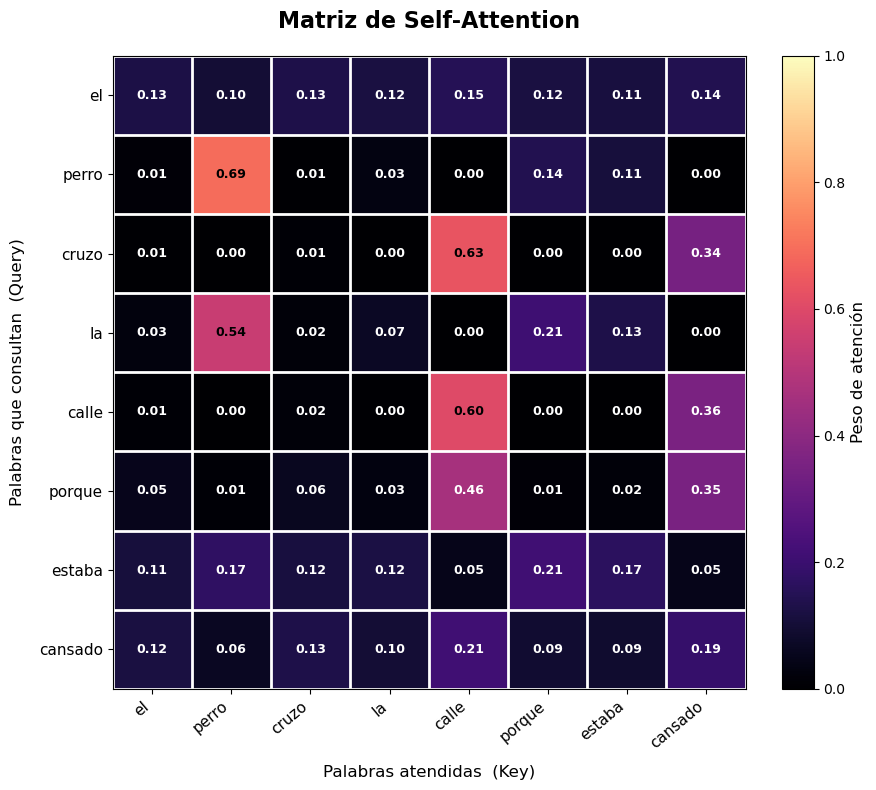

In [133]:
fig, ax = plt.subplots(figsize=(10, 8))

# Mapa de calor con anotaciones numéricas en cada celda
im = ax.imshow(pesos_atencion, cmap="magma", vmin=0, vmax=1)

# Anotaciones numéricas dentro de cada celda
for i in range(num_tokens):
    for j in range(num_tokens):
        valor = pesos_atencion[i, j]
        # Color del texto según fondo para mejor legibilidad
        color_texto = "white" if valor < 0.5 else "black"
        ax.text(j, i, f"{valor:.2f}",
                ha="center", va="center",
                fontsize=9, color=color_texto, fontweight="bold")

# Barra de color
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Peso de atención", fontsize=12)
cbar.ax.tick_params(labelsize=10)

# Etiquetas
ax.set_xticks(range(num_tokens))
ax.set_yticks(range(num_tokens))
ax.set_xticklabels(palabras, rotation=40, ha="right", fontsize=11)
ax.set_yticklabels(palabras, fontsize=11)

# Líneas separadoras entre celdas
ax.set_xticks(np.arange(-0.5, num_tokens, 1), minor=True)
ax.set_yticks(np.arange(-0.5, num_tokens, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", size=0)

# Títulos
ax.set_title("Matriz de Self-Attention", fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Palabras atendidas  (Key)", fontsize=12, labelpad=10)
ax.set_ylabel("Palabras que consultan  (Query)", fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

# BLOQUE B 

In [142]:
# Mini encoder para transformers para clasificación

# Dataset sintético balanceado — 10 positivas (1) y 10 negativas (0)
# Vocabulario controlado para que el modelo aprenda patrones claros
frases = [
    # Frases positivas — vocabulario: excelente, útil, claro, brillante, correcto...
    "la clase fue excelente y clara", "el curso fue util y ordenado", "la explicacion fue precisa y brillante",  
    "la practica fue interesante y completa", "el modelo funciono correctamente","la sesion fue muy buena",
    "el ejemplo fue claro y util", "la actividad fue excelente", "el resultado fue estable y correcto",
    "la explicacion fue ordenada",
    # Frases negativas — vocabulario: confusa, aburrido, pobre, terrible, malo...
    "la clase fue confusa y pesada", "el curso fue aburrido y malo", "la explicacion fue pobre y desordenada",
    "la practica fue terrible", "el modelo fallo constantemente",  "la sesion fue muy mala",
    "el ejemplo fue confuso", "la actividad fue deficiente", "el resultado fue inestable e incorrecto",
    "la explicacion fue desordenada"
]


In [152]:
# Etiquetas binarias: 1=positivo, 0=negativo — alineadas con frases por índice
etiquetas = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
             0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

# DataFrame para inspección visual y manejo estructurado del dataset
df = pd.DataFrame({
    "frase"   : frases,     # columna de texto crudo
    "etiqueta": etiquetas   # columna de labels (target)
})

# --- Mezcla Aleatoria (Shuffle) ---
# Es crucial que el modelo no reciba primero todos los ceros y luego todos los unos.
# .sample(frac=1): Toma el 100% de los datos y los desordena al azar.
# random_state=42: Asegura que el "desorden" sea reproducible (siempre el mismo).
# .reset_index(drop=True): Reorganiza los números de fila para que vayan de 0 en adelante.
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df

,frase,etiqueta
0,la clase fue excelente y clara,1
1,la actividad fue deficiente,0
2,la sesion fue muy mala,0
3,el curso fue util y ordenado,1
4,el resultado fue estable y correcto,1
5,la sesion fue muy buena,1
6,el curso fue aburrido y malo,0
7,la practica fue interesante y completa,1
8,el resultado fue inestable e incorrecto,0
9,el ejemplo fue confuso,0


In [154]:
# Imprimimos la cantidad total de oraciones recolectadas.
print("\nTotal de ejemplos:", len(df))

# --- Verificación de Balance ---
# Contamos cuántos ejemplos hay de cada clase. 
# Esto asegura que no haya un desbalance que pueda confundir al modelo.
print("\nBalance de clases:")
print(df["etiqueta"].value_counts())


Total de ejemplos: 20

Balance de clases:
etiqueta
1    10
0    10
Name: count, dtype: int64


In [158]:
# Tokenizamos y paddeamos

# Extraemos columnas del DataFrame como listas planas
X_texto = df["frase"].tolist()     # ["la clase fue excelente...", ...]
y = df["etiqueta"].tolist()         # [1, 1, 1, ..., 0, 0, 0]

# Split estratificado → respeta proporción 50/50 en train y test
X_train_texto, X_test_texto, y_train, y_test = train_test_split(
    X_texto, y,
    test_size=0.25,      # 5 frases test, 15 frases train
    random_state=42,     # reproducibilidad
    stratify=y           # evita que test quede todo positivo o todo negativo
)

# Crea el vocabulario SOLO con datos de train → simula condiciones reales
# oov_token="<OOV>" → palabras de test no vistas en train → índice 1
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_texto)   # aprende: "excelente"→8, "confusa"→12...

word_index = tokenizer.word_index       # diccionario completo palabra→índice
vocab_size = len(word_index) + 1        # +1 porque índice 0 está reservado al padding

# Convierte frases en secuencias de índices enteros
X_train_seq = tokenizer.texts_to_sequences(X_train_texto)
# "la clase fue excelente" → [3, 6, 2, 8]

X_test_seq = tokenizer.texts_to_sequences(X_test_texto)
# usa el vocabulario aprendido en train — palabras nuevas → 1 (<OOV>)

# Longitud de la frase más larga en train → referencia para igualar todo
max_len = max(len(seq) for seq in X_train_seq)

# Padding post → rellena con zeros al final hasta alcanzar max_len
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
# [3, 6, 2, 8]  →  [3, 6, 2, 8, 0, 0, 0]

X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post")
# misma config que train — obligatorio para que el modelo reciba forma consistente

In [160]:
X_train_pad

array([[ 3,  7,  2,  8,  4, 14],
       [ 3,  6,  2, 15,  4, 16],
       [ 5,  9,  2, 10,  4, 17],
       [ 3,  6,  2, 18,  0,  0],
       [ 3, 11,  2, 12, 19,  0],
       [ 3,  7,  2, 20,  4, 21],
       [ 5, 22, 23, 24,  0,  0],
       [ 5, 25,  2, 26,  4, 27],
       [ 3,  6,  2, 28,  0,  0],
       [ 3, 11,  2, 12, 29,  0],
       [ 5, 30,  2, 31,  4, 10],
       [ 3, 32,  2, 33,  0,  0],
       [ 5,  9,  2, 34,  4, 35],
       [ 3, 13,  2,  8,  0,  0],
       [ 3, 13,  2, 36,  0,  0]])

In [166]:
# Convertimos listas Python a arrays NumPy — formato que espera TensorFlow
y_train_np = np.array(y_train)   # shape: (15,) → [1, 0, 1, 1, 0 ...]
y_test_np  = np.array(y_test)    # shape: (5,)  → [1, 0, 1, 0, 1]

In [170]:
# Encabezados de la tabla
print(f"{'Índice':<10} | {'Palabra':<20}")
print("-" * 35)

# Recorremos el word_index y lo imprimimos con formato de tabla
# Usamos < para alinear a la izquierda y el número para el ancho de la columna
for palabra, indice in list(word_index.items())[:25]:
    print(f"{indice:<10} | {palabra:<20}")

print("-" * 35)

Índice     | Palabra             
-----------------------------------
1          | <OOV>               
2          | fue                 
3          | la                  
4          | y                   
5          | el                  
6          | explicacion         
7          | clase               
8          | excelente           
9          | curso               
10         | util                
11         | sesion              
12         | muy                 
13         | actividad           
14         | clara               
15         | precisa             
16         | brillante           
17         | ordenado            
18         | desordenada         
19         | buena               
20         | confusa             
21         | pesada              
22         | modelo              
23         | fallo               
24         | constantemente      
25         | resultado           
-----------------------------------


In [172]:
# Función de posicionamiento del encoding
def crear_positional_encoding(longitud_secuencia, dimension_modelo):

    # Matriz de ceros shape: (longitud_secuencia, dimension_modelo)
    # cada fila = vector de posición para un token
    positional_encoding = np.zeros((longitud_secuencia, dimension_modelo))

    for pos in range(longitud_secuencia):        # pos = posición del token en la secuencia
        for i in range(dimension_modelo):        # i   = dimensión del embedding

            # Denominador de la fórmula original del paper "Attention is All You Need"
            # crece exponencialmente → frecuencias distintas por dimensión
            denominador = np.power(
                10000,
                (2 * (i // 2)) / dimension_modelo  # i//2 agrupa pares: 0,0,1,1,2,2...
            )

            # Dimensiones PARES → seno
            # PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
            if i % 2 == 0:
                positional_encoding[pos, i] = np.sin(pos / denominador)

            # Dimensiones IMPARES → coseno
            # PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
            else:
                positional_encoding[pos, i] = np.cos(pos / denominador)

    # Agregamos dimensión de batch al inicio: (seq_len, d_model) → (1, seq_len, d_model)
    # permite sumar directamente a embeddings de shape (batch, seq_len, d_model)
    positional_encoding = positional_encoding[np.newaxis, ...]

    # Convertimos a tensor TF float32 — formato nativo de Keras
    return tf.cast(positional_encoding, dtype=tf.float32)

In [174]:
# Capa personalizada del positional encoding
# Clase personalizada que hereda de tf.keras.layers.Layer
class PositionalEncodingLayer(tf.keras.layers.Layer):

    # Constructor — se ejecuta UNA vez al crear la capa
    def __init__(self, max_len, dimension_modelo):
        super(PositionalEncodingLayer, self).__init__()  # inicializa la clase padre Layer
        self.max_len = max_len                           # longitud máxima de secuencia soportada
        self.dimension_modelo = dimension_modelo         # debe coincidir con el embedding_dim del modelo

        # Pre-calculamos el encoding UNA sola vez y lo guardamos
        # no es un peso entrenable — es una constante matemática fija
        self.positional_encoding = crear_positional_encoding(
            max_len,
            dimension_modelo
        )   # shape: (1, max_len, dimension_modelo)

    # call — se ejecuta en CADA pasada forward (cada batch)
    def call(self, x):
        # x.shape = (batch, longitud_actual, dimension_modelo)
        longitud_actual = tf.shape(x)[1]   # longitud real de la secuencia del batch

        # Recortamos el encoding a la longitud real — evita usar padding innecesario
        # pe_recortado.shape = (1, longitud_actual, dimension_modelo)
        pe_recortado = self.positional_encoding[:, :longitud_actual, :]

        # Sumamos posición al embedding → broadcasting expande batch automáticamente
        # (batch, seq, d_model) + (1, seq, d_model) = (batch, seq, d_model)
        return x + pe_recortado

## Encoder

![Transformer Encoder](transformer_encoder_block.png)

In [198]:
# Bloque del encoder del Transformer
def transformer_encoder_bloque(x, num_head, key_dim, ff_dim, dropout_rate=0.1):

    # ═══════════════════════════════════════
    # PARTE 1 — Multi-Head Self-Attention
    # ═══════════════════════════════════════

    # x,x,x → Query, Key y Value vienen del MISMO tensor (self-attention)
    # num_head → número de "cabezas" de atención en paralelo
    # key_dim   → dimensión de cada cabeza (d_k)
    attention_output = MultiHeadAttention(
        num_heads=num_head,
        key_dim=key_dim
    )(x, x)   # (query=x, value=x) → Keras infiere key=x automáticamente

    # Dropout sobre la salida de atención → regularización
    # apaga neuronas aleatoriamente durante entrenamiento
    attention_output = Dropout(dropout_rate)(attention_output)

    # Conexión residual → suma el input original a la salida de atención
    # permite que los gradientes fluyan directo hacia atrás sin desvanecerse
    x = x + attention_output

    # Layer Normalization → estabiliza la distribución de activaciones
    # epsilon=1e-6 evita división por cero en la normalización
    x = LayerNormalization(epsilon=1e-6)(x)

    # ═══════════════════════════════════════
    # PARTE 2 — Feed Forward Network (FFN)
    # ═══════════════════════════════════════

    # Primera capa — expande la representación a dimensión mayor
    # ff_dim > d_model → crea espacio para aprender transformaciones complejas
    # relu → introduce no linealidad (sin esto solo habría transformaciones lineales)
    ffn_output = Dense(ff_dim, activation="relu")(x)

    # Segunda capa — comprime de vuelta a la dimensión original
    # x.shape[-1] = dimension_modelo → misma dim que el input para poder sumar
    ffn_output = Dense(x.shape[-1])(ffn_output)

    # Dropout sobre la salida del FFN → regularización
    ffn_output = Dropout(dropout_rate)(ffn_output)

    # Conexión residual → suma el input al resultado del FFN
    x = x + ffn_output

    # Layer Normalization final → estabiliza antes de pasar al siguiente bloque
    x = LayerNormalization(epsilon=1e-6)(x)

    return x   # shape idéntico al input → bloques apilables

In [202]:
# Construimos el modelo Transformer

# ── Hiperparámetros ───────────────────────────────────────────────────────
dimension_modelo = 32   # d_model: dimensión de embeddings y de cada token a lo largo del modelo
num_heads        = 2    # cabezas de atención en paralelo — cada una aprende relaciones distintas
key_dim          = 16   # dimensión por cabeza: dimension_modelo / num_heads = 32/2 = 16 ✅
ffn_dim          = 64   # dimensión de expansión del FFN — típicamente 2×-4× d_model

# ── Entrada ───────────────────────────────────────────────────────────────
input_layer = Input(
    shape=(max_len,),    # secuencia de índices enteros — shape: (batch, max_len)
    name="entrada_tokens"
)

# ── Embedding ─────────────────────────────────────────────────────────────
embedding_layer = Embedding(
    input_dim=vocab_size,       # tamaño del vocabulario — una fila por palabra
    output_dim=dimension_modelo, # cada índice → vector de 32 dimensiones
    name="embedding_tokens"
)(input_layer)                  # shape: (batch, max_len, 32)

# ── Positional Encoding ───────────────────────────────────────────────────
# Sumamos información de posición a los embeddings
# sin esto el modelo no sabe el orden de las palabras
x = PositionalEncodingLayer(
    max_len=max_len,
    dimension_modelo=dimension_modelo
)(embedding_layer)              # shape: (batch, max_len, 32) — misma forma, + posición

# ── Bloque Encoder ────────────────────────────────────────────────────────
# Self-Attention + FFN + conexiones residuales + Layer Norm
x = transformer_encoder_bloque(
    x=x,
    num_head=num_heads,    # 2 cabezas de atención
    key_dim=key_dim,       # 16 dims por cabeza
    ff_dim=ffn_dim,        # expansión interna del FFN a 64 dims
    dropout_rate=0.1       # regularización dentro del bloque
)                          # shape: (batch, max_len, 32) — forma preservada

# ── Clasificador ─────────────────────────────────────────────────────────
x = GlobalAveragePooling1D()(x)  # colapsa tokens → promedia toda la secuencia
                                  # shape: (batch, 32) — de 3D a 2D

x = Dense(32, activation="relu")(x)  # capa densa intermedia — aprende combinaciones
                                       # shape: (batch, 32)

x = Dropout(0.2)(x)              # regularización más agresiva antes de la salida
                                  # evita overfitting en dataset pequeño (20 frases)

output_layer = Dense(
    1,
    activation="sigmoid"          # salida binaria: probabilidad de ser positivo (0-1)
)(x)                              # shape: (batch, 1)

# ── Ensamblado del modelo ─────────────────────────────────────────────────
modelo_transformer = Model(
    inputs=input_layer,
    outputs=output_layer,
    name="mini_transformer"
)

# ── Compilación ───────────────────────────────────────────────────────────
modelo_transformer.compile(
    optimizer=Adam(learning_rate=0.001),  # Adam estándar — lr=0.001 es el default
    loss="binary_crossentropy",           # pérdida para clasificación binaria (0/1)
    metrics=["accuracy"]                  # métrica legible durante entrenamiento
)

modelo_transformer.summary()             # imprime arquitectura completa con shapes y parámetros

Model: "mini_transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ entrada_tokens (InputLayer)   │ (None, 6)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_tokens (Embedding)  │ (None, 6, 32)             │           1,184 │ entrada_tokens[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ positional_encoding_layer_8   │ (None, 6, 32)             │               0 │ embedding_tokens[0][0]     │
│ (PositionalEncodingLayer)     │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention_1        │ (None, 6, 32)             │           4,224 │ positional_encoding_layer… │
│ (MultiHeadAttention)          │                           │                 │ positional_encoding_layer… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_5 (Dropout)           │ (None, 6, 32)             │               0 │ multi_head_attention_1[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_2 (Add)                   │ (None, 6, 32)             │               0 │ positional_encoding_layer… │
│                               │                           │                 │ dropout_5[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_2         │ (None, 6, 32)             │              64 │ add_2[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 6, 64)             │           2,112 │ layer_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 6, 32)             │           2,080 │ dense_4[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_6 (Dropout)           │ (None, 6, 32)             │               0 │ dense_5[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_3 (Add)                   │ (None, 6, 32)             │               0 │ layer_normalization_2[0][… │
│                               │                           │                 │ dropout_6[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_3         │ (None, 6, 32)             │              64 │ add_3[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d_1    │ (None, 32)                │               0 │ layer_normalization_3[0][… │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 32)                │           1,05

 Total params: 10,817 (42.25 KB)

 Trainable params: 10,817 (42.25 KB)

 Non-trainable params: 0 (0.00 B)

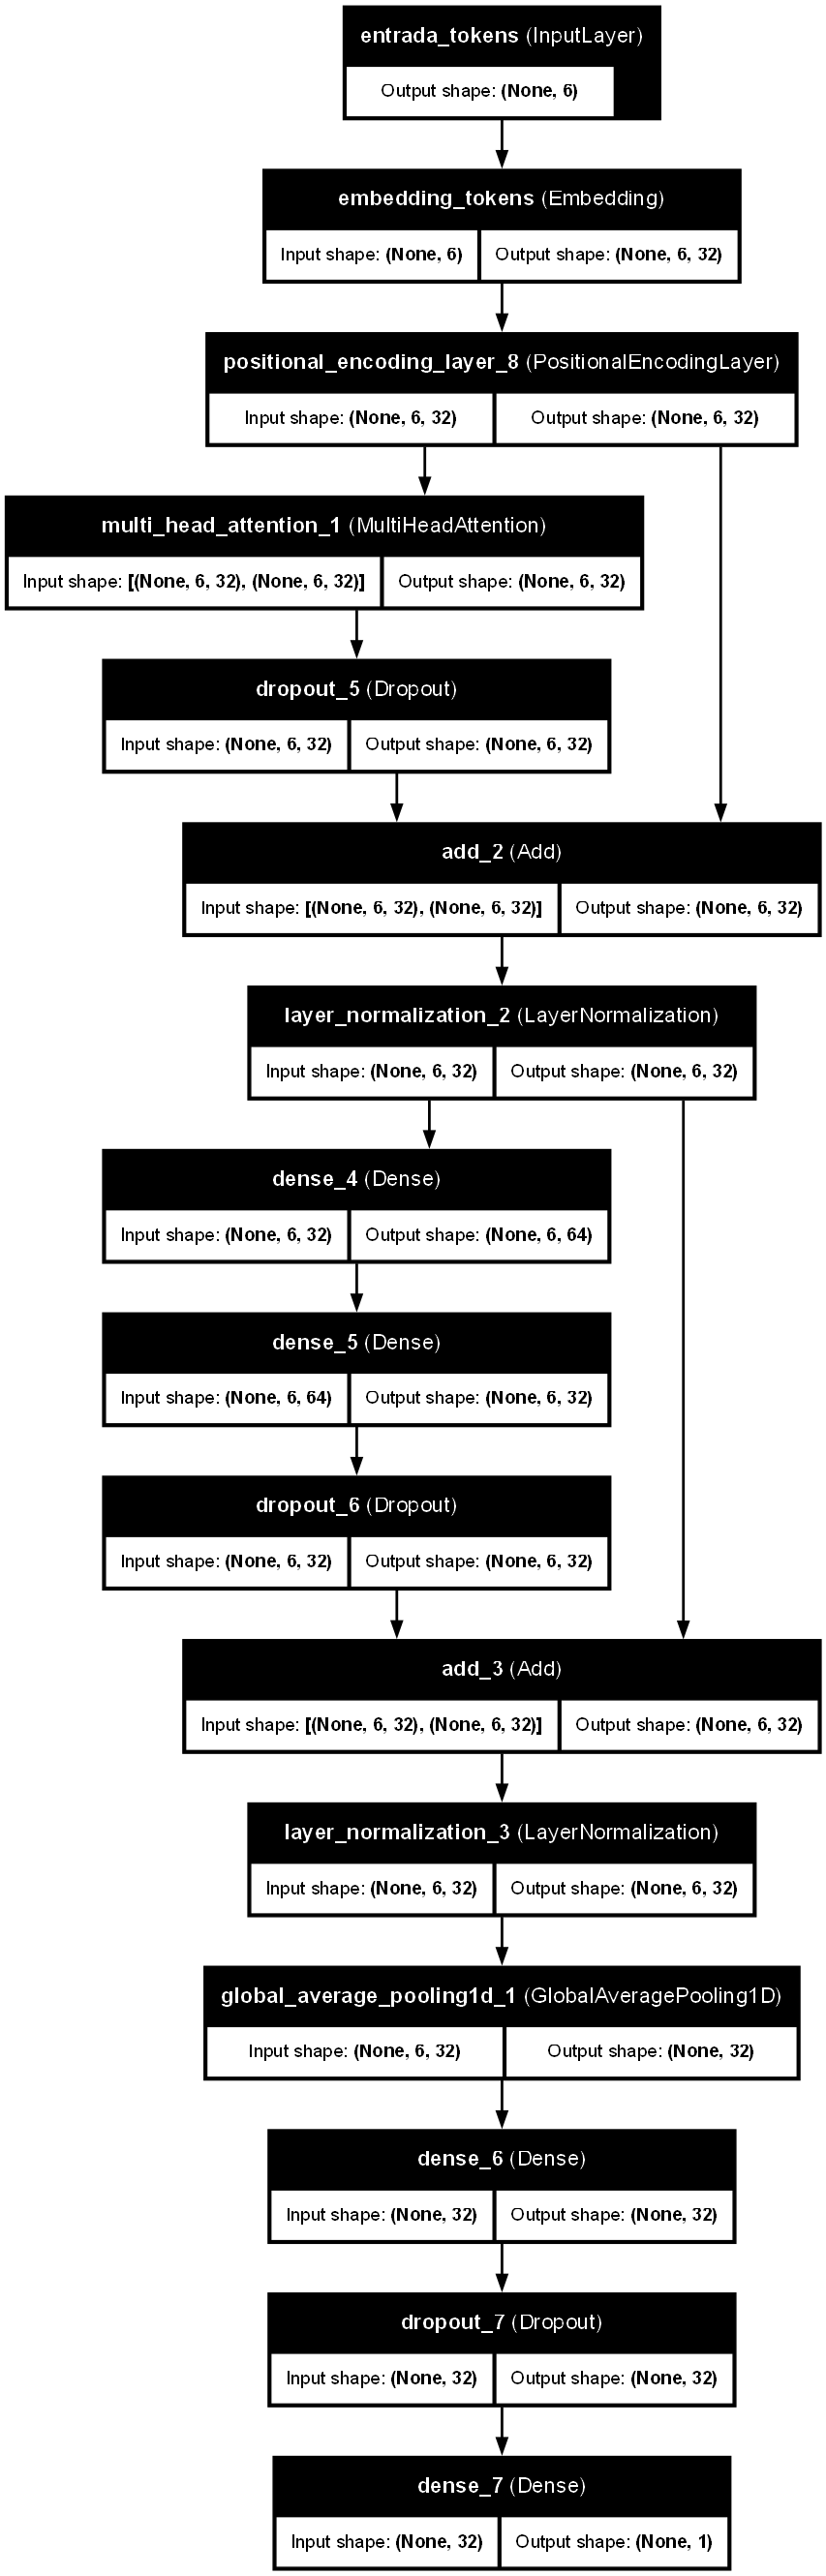

In [206]:
from tensorflow.keras.utils import plot_model

plot_model(
    modelo_transformer,
    to_file="modelo_transformer.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=100
)

In [220]:
# Entrenamos el mini transformer
historial = modelo_transformer.fit(
    X_train_pad,      # secuencias paddeadas de entrenamiento — shape: (15, max_len)
    y_train_np,       # etiquetas binarias 0/1 — shape: (15,)
    epochs=60,        # pasadas completas sobre el dataset — suficiente para dataset pequeño
    batch_size=4,     # 4 frases por actualización de pesos — balance entre estabilidad y velocidad
    validation_split=0.2,  # 20% del train → validación (~3 frases) para monitorear overfitting
    verbose=0         # sin output por época — historial guardado en la variable historial
)

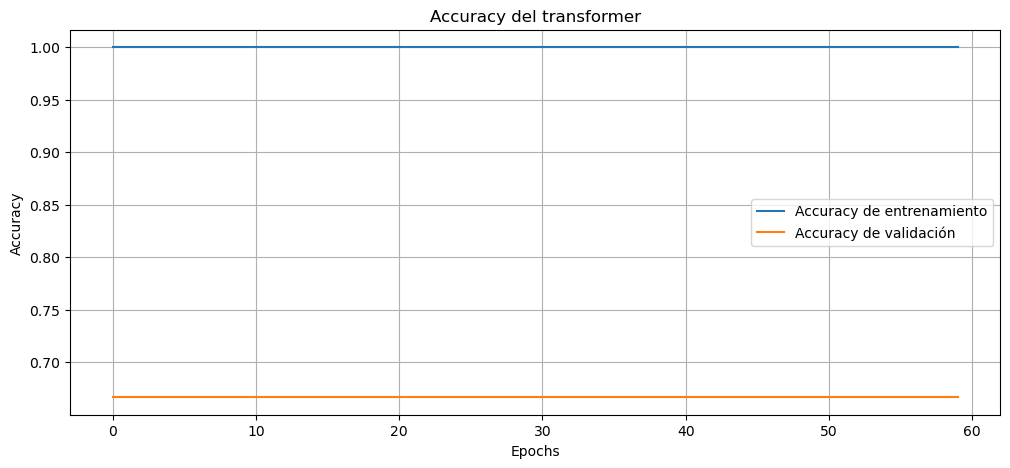

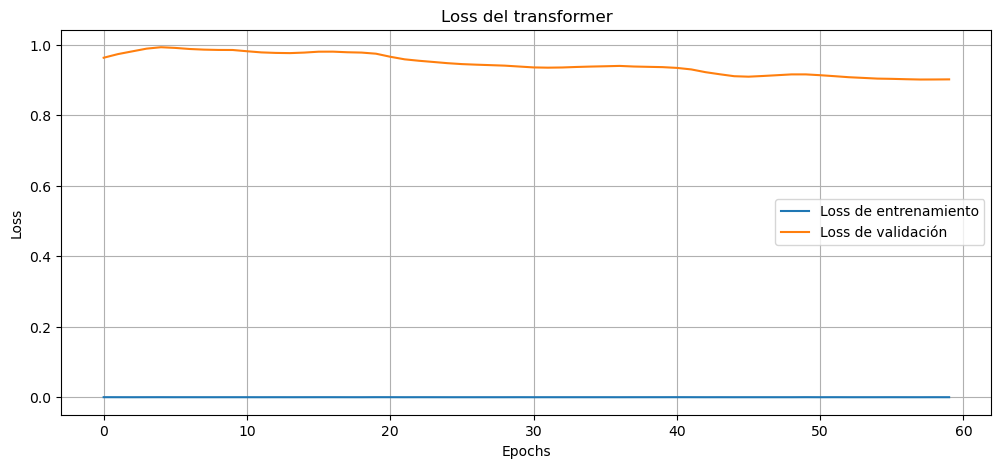

In [221]:
# Gráficas de entrenamiento — dos figuras separadas: accuracy y loss

# ── Gráfica 1: Accuracy ───────────────────────────────────────────────────
plt.figure(figsize=(12, 5))

plt.plot(historial.history["accuracy"],     label="Accuracy de entrenamiento")  # curva train
plt.plot(historial.history["val_accuracy"], label="Accuracy de validación")     # curva val

plt.title("Accuracy del transformer")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)   # cuadrícula para leer valores con más facilidad
plt.show()

# ── Gráfica 2: Loss ───────────────────────────────────────────────────────
plt.figure(figsize=(12, 5))

plt.plot(historial.history["loss"],     label="Loss de entrenamiento")  # binary_crossentropy train
plt.plot(historial.history["val_loss"], label="Loss de validación")     # binary_crossentropy val

plt.title("Loss del transformer")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [224]:
# Probamos frases nuevas — inferencia sobre datos nunca vistos

frases_nuevas = [
    "la clase fue excelente",        # positiva esperada ✅
    "la explicacion fue confusa",    # negativa esperada ✅
    "el modelo funciono correctamente", # positiva esperada ✅
    "la practica fue terrible",      # negativa esperada ✅
    "el resultado fue estable y correcto" # positiva esperada ✅
]

# Mismo pipeline que en entrenamiento — obligatorio para consistencia
seq_nuevas = tokenizer.texts_to_sequences(frases_nuevas)
# palabras fuera del vocabulario de train → índice 1 (<OOV>)

pad_nuevas = pad_sequences(
    seq_nuevas,
    maxlen=max_len,   # misma longitud que en train — el modelo espera esta forma
    padding="post"    # misma config que en train — obligatorio
)

# Inferencia — el modelo devuelve probabilidades entre 0 y 1 (sigmoid)
predicciones = modelo_transformer.predict(pad_nuevas, verbose=0)
# shape: (5, 1) → una probabilidad por frase

for i, frase in enumerate(frases_nuevas):
    print("Frase:", frase)
    print(f"Probabilidad positiva: {predicciones[i][0]:.4f}")

    if predicciones[i][0] >= 0.6:             # umbral alto → confianza positiva
        print("Clasificación: POSITIVA ✅")
    elif predicciones[i][0] > 0.5:            # zona gris → modelo inseguro
        print("Clasificación: el modelo está dudando 🤔")
    else:                                      # por debajo de 0.5 → negativa
        print("Clasificación: NEGATIVA ❌")

    print("-" * 70)

Frase: la clase fue excelente
Probabilidad positiva: 0.9816
Clasificación: POSITIVA ✅
----------------------------------------------------------------------
Frase: la explicacion fue confusa
Probabilidad positiva: 0.0000
Clasificación: NEGATIVA ❌
----------------------------------------------------------------------
Frase: el modelo funciono correctamente
Probabilidad positiva: 0.0000
Clasificación: NEGATIVA ❌
----------------------------------------------------------------------
Frase: la practica fue terrible
Probabilidad positiva: 0.0000
Clasificación: NEGATIVA ❌
----------------------------------------------------------------------
Frase: el resultado fue estable y correcto
Probabilidad positiva: 1.0000
Clasificación: POSITIVA ✅
----------------------------------------------------------------------
